In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression


In [76]:
X,y=make_regression(n_samples=1000,n_features=2,n_targets=1,noise=3.0)

In [77]:
X

array([[ 0.14644155, -0.77970415],
       [ 2.05946483, -0.73398469],
       [-0.84584533,  0.40340888],
       ...,
       [-0.14475386,  0.31802876],
       [ 1.37183537,  0.5580198 ],
       [ 0.68618939,  2.5155707 ]])

In [78]:
y

array([-2.71608394e+01,  7.26025293e+01, -2.42580502e+01,  1.53315682e+02,
        6.07817533e+01,  1.22355489e+02,  1.92664993e+01, -2.52969627e+01,
       -3.68708034e+01,  3.95527867e+01,  4.74984389e+01,  7.60241793e+01,
       -8.95244970e+01, -7.96884759e+01, -1.55628980e+00,  5.81405965e+01,
       -5.74080681e+01,  1.64751987e+02,  8.40075698e+01,  2.55178171e+01,
       -7.30663640e+01, -1.26606244e+02,  1.09470625e+01,  3.06597590e+01,
        1.49870937e+02,  8.59336575e+01, -2.40769910e+01, -1.03534447e+02,
       -4.80973632e+01, -6.21777908e+01, -8.48894484e+00, -8.11509819e+01,
       -4.70305539e+01,  1.20994952e+01,  3.55967231e+01,  1.49233066e+01,
       -2.17309793e+01, -2.51369230e+01, -4.62700812e+01, -1.59919642e+02,
       -5.96318378e+01, -1.60797531e+01, -2.56947920e+01,  3.62180253e+01,
        2.30429807e+01,  3.62197114e-01,  7.75288076e+01,  1.21328344e+01,
        7.53108297e+01, -1.41181835e+02, -2.39731430e+01,  2.17618692e+01,
        5.41279104e+01,  

<Axes: xlabel='0', ylabel='1'>

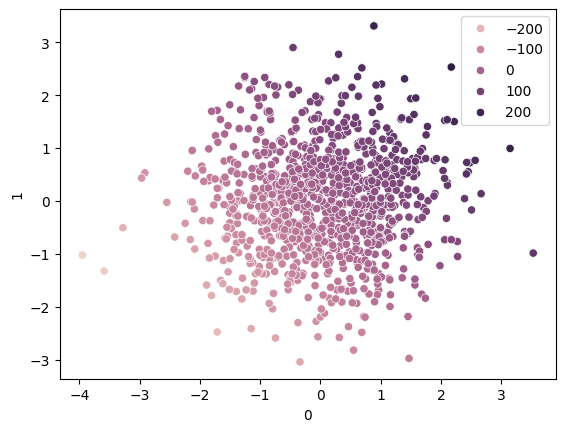

In [79]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [80]:
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=10)

In [81]:
from sklearn.svm import SVR

In [82]:
svr=SVR()

In [83]:
svr.fit(X_train,y_train)

SVR()

In [84]:
y_pred=svr.predict(x_test)

In [85]:
from sklearn.metrics import r2_score

In [86]:
print(r2_score(y_pred,y_test))
print(r2_score(y_test,y_pred))

0.5693679247913468
0.7853804671681947


Hyperparameter Tuning

In [87]:
from sklearn.model_selection import GridSearchCV

In [92]:
para={
    'C':[0.1,1,10,100,1000],
    'gamma':[1,0.1,0.01,0.001,0.0001],
    'kernel':['linear'],
    'epsilon':[0.1,0.2,0.3,0.4,0.5]
}

In [93]:
grid=GridSearchCV(SVR(),param_grid=para,refit=True,verbose=3,cv=5)

In [94]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 125 candidates, totalling 625 fits
[CV 1/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.906 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.915 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.906 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.925 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=1, kernel=linear;, score=0.921 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.906 total time=   0.0s
[CV 2/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.915 total time=   0.0s
[CV 3/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.906 total time=   0.0s
[CV 4/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.925 total time=   0.0s
[CV 5/5] END C=0.1, epsilon=0.1, gamma=0.1, kernel=linear;, score=0.921 total time=   0.0s
[CV 1/5] END C=0.1, epsilon=0.1, gamm

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'epsilon': [0.1, 0.2, 0.3, 0.4, 0.5],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['linear']},
             verbose=3)

In [95]:
grid.best_params_

{'C': 10, 'epsilon': 0.1, 'gamma': 1, 'kernel': 'linear'}

In [96]:
y_pred=grid.predict(x_test)
print(r2_score(y_test,y_pred))
print(r2_score(y_pred,y_test))

0.9984128831709618
0.9984249588776121
